In [ ]:
%matplotlib inline
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pyEXP

sys.path.append("./exp_pipeline/")
from field_io import write_fields, read_fields

In [2]:
sys.path.append("./exp_pipeline/")
from density_dashboard import compute_dashboard
from ios_nbody_sims import load_particle_data
from compute_bfe_helpers import load_sheng24_exp_center
from basis_utils import load_basis


In [3]:
# Load data

p = load_particle_data("../suites/Sheng24/data/Model_108/", snapname="snapshot", components=["MWhalo"], nsnap=0, suite="Sheng24", 
                       quantities=["pos", "mass", "pot"])

[INFO] Header 'Time': 0.0
[INFO] Header 'Redshift': 0.0
[INFO] Header 'BoxSize': 0.0
[INFO] Header 'NumPart_Total': [     0 849690  68000   5000      0      0]
[INFO] Header 'MassTable': [0. 0. 0. 0. 0. 0.]


In [4]:
# load centers
sim_centers = load_sheng24_exp_center(
    origin_dir="../data/",
    centers_filename="MW_LMC_orbits_iso.txt",
    sim_id=108, return_vel=True)

In [5]:
os.chdir("./exp_expansions/tests/")

In [6]:
config_name = "basis_halo_0108.yaml"
basis = load_basis(config_name)

---- SLGridSph::ReadH5Cache: successfully read basis cache <cache_halo_0108.txt>
---- Spherical::orthoTest: worst=0.0285643


In [7]:
coefs = pyEXP.coefs.Coefs.factory("halo_0108_coefficients.h5")

In [8]:
times = coefs.Times()

In [9]:
coefs.Power()

array([[7.60876888e+02, 4.64057692e-03],
       [7.60259401e+02, 3.04282229e-02],
       [7.59922961e+02, 2.66688575e-01],
       [7.58942161e+02, 9.83373248e-01],
       [7.57140971e+02, 2.87211569e+00],
       [7.53041425e+02, 6.94142882e+00],
       [7.45225316e+02, 1.46885336e+01],
       [7.31392921e+02, 2.72377281e+01],
       [7.08888739e+02, 4.66039492e+01],
       [6.76353293e+02, 7.21568392e+01],
       [6.35691477e+02, 1.03410675e+02]])

In [10]:
nbins = 20
dbins = np.linspace(-100, 100, nbins)
grid = np.meshgrid(dbins, dbins, dbins)

mesh = np.zeros((nbins**3, 3))
mesh[:,0] = grid[0].flatten()
mesh[:,1] = grid[1].flatten()
mesh[:,2] = grid[2].flatten()
		

In [11]:
fields = pyEXP.field.FieldGenerator(coefs.Times(), mesh)
points = fields.points(basis, coefs)

In [12]:
write_fields(points, "test_fields_file.h5", grid=grid[0])

Fields written to test_fields_file.h5


In [14]:
f = read_fields("test_fields_file.h5", time=0.0, field='dens')

array([[[2.1227646e-07, 2.4143387e-07, 2.6960103e-07, ...,
         2.7047045e-07, 2.4226875e-07, 2.1305100e-07],
        [2.4128099e-07, 2.7310642e-07, 3.0400301e-07, ...,
         3.0505288e-07, 2.7411247e-07, 2.4221410e-07],
        [2.6926193e-07, 3.0381418e-07, 3.4366002e-07, ...,
         3.4491396e-07, 3.0500402e-07, 2.7036319e-07],
        ...,
        [2.6758809e-07, 3.0203148e-07, 3.4182833e-07, ...,
         3.4308223e-07, 3.0322133e-07, 2.6868938e-07],
        [2.3951719e-07, 2.7119404e-07, 3.0198262e-07, ...,
         3.0303249e-07, 2.7220011e-07, 2.4045028e-07],
        [2.1048784e-07, 2.3946254e-07, 2.6748086e-07, ...,
         2.6835028e-07, 2.4029742e-07, 2.1126237e-07]],

       [[2.4135147e-07, 2.7321650e-07, 3.0416166e-07, ...,
         3.0521153e-07, 2.7422254e-07, 2.4228459e-07],
        [2.7304480e-07, 3.0802153e-07, 3.5050905e-07, ...,
         3.5179295e-07, 3.0923684e-07, 2.7416922e-07],
        [3.0378399e-07, 3.5030149e-07, 4.0660129e-07, ...,
         4.081

In [33]:
# Inspect inner values
first_time = list(points.keys())[0]
for field_name, arr in points[first_time].items():
    print(f"  field={field_name!r}, type={type(arr).__name__}, shape={np.array(arr).shape}, dtype={np.array(arr).dtype}")

  field='azi force', type=ndarray, shape=(8000,), dtype=float32
  field='dens', type=ndarray, shape=(8000,), dtype=float32
  field='dens m=0', type=ndarray, shape=(8000,), dtype=float32
  field='dens m>0', type=ndarray, shape=(8000,), dtype=float32
  field='mer force', type=ndarray, shape=(8000,), dtype=float32
  field='potl', type=ndarray, shape=(8000,), dtype=float32
  field='potl m=0', type=ndarray, shape=(8000,), dtype=float32
  field='potl m>0', type=ndarray, shape=(8000,), dtype=float32
  field='rad force', type=ndarray, shape=(8000,), dtype=float32


Computing EXP fields...
Computing KDE density...
---- KDdensity: finished density estimate with 0 undetermined densities, mass=69.6807
---- KDdensity: a few densities are 1.4733e-05, 1.65575e-13, 0.000176621
---- KDdensity: bad density count is 0 of 704000 particles.
Computing MISE & MIRSE...
Plotting dashboard...
Computing EXP fields...
Computing KDE density...
---- KDdensity: finished density estimate with 0 undetermined densities, mass=69.6807
---- KDdensity: a few densities are 1.4733e-05, 1.65575e-13, 0.000176621
---- KDdensity: bad density count is 0 of 704000 particles.
Computing MISE & MIRSE...
Plotting dashboard...
Computing EXP fields...
Computing KDE density...
---- KDdensity: finished density estimate with 0 undetermined densities, mass=69.6807
---- KDdensity: a few densities are 1.4733e-05, 1.65575e-13, 0.000176621
---- KDdensity: bad density count is 0 of 704000 particles.
Computing MISE & MIRSE...
Plotting dashboard...
Computing EXP fields...
Computing KDE density...
---

/home/ngc/Work/research/XMC-Atlas/scripts/density_dashboard.py:59: RuntimeWarning: invalid value encountered in log10
  np.log10(dens_bfe),


Computing EXP fields...
Computing KDE density...
---- KDdensity: finished density estimate with 0 undetermined densities, mass=69.6807
---- KDdensity: a few densities are 1.4733e-05, 1.65575e-13, 0.000176621
---- KDdensity: bad density count is 0 of 704000 particles.
Computing MISE & MIRSE...
Plotting dashboard...


/home/ngc/Work/research/XMC-Atlas/scripts/density_dashboard.py:59: RuntimeWarning: invalid value encountered in log10
  np.log10(dens_bfe),


Computing EXP fields...
Computing KDE density...
---- KDdensity: finished density estimate with 0 undetermined densities, mass=69.6807
---- KDdensity: a few densities are 1.4733e-05, 1.65575e-13, 0.000176621
---- KDdensity: bad density count is 0 of 704000 particles.
Computing MISE & MIRSE...
Plotting dashboard...


/home/ngc/Work/research/XMC-Atlas/scripts/density_dashboard.py:59: RuntimeWarning: invalid value encountered in log10
  np.log10(dens_bfe),


Computing EXP fields...
Computing KDE density...
---- KDdensity: finished density estimate with 0 undetermined densities, mass=69.6807
---- KDdensity: a few densities are 1.4733e-05, 1.65575e-13, 0.000176621
---- KDdensity: bad density count is 0 of 704000 particles.
Computing MISE & MIRSE...
Plotting dashboard...


/home/ngc/Work/research/XMC-Atlas/scripts/density_dashboard.py:59: RuntimeWarning: invalid value encountered in log10
  np.log10(dens_bfe),


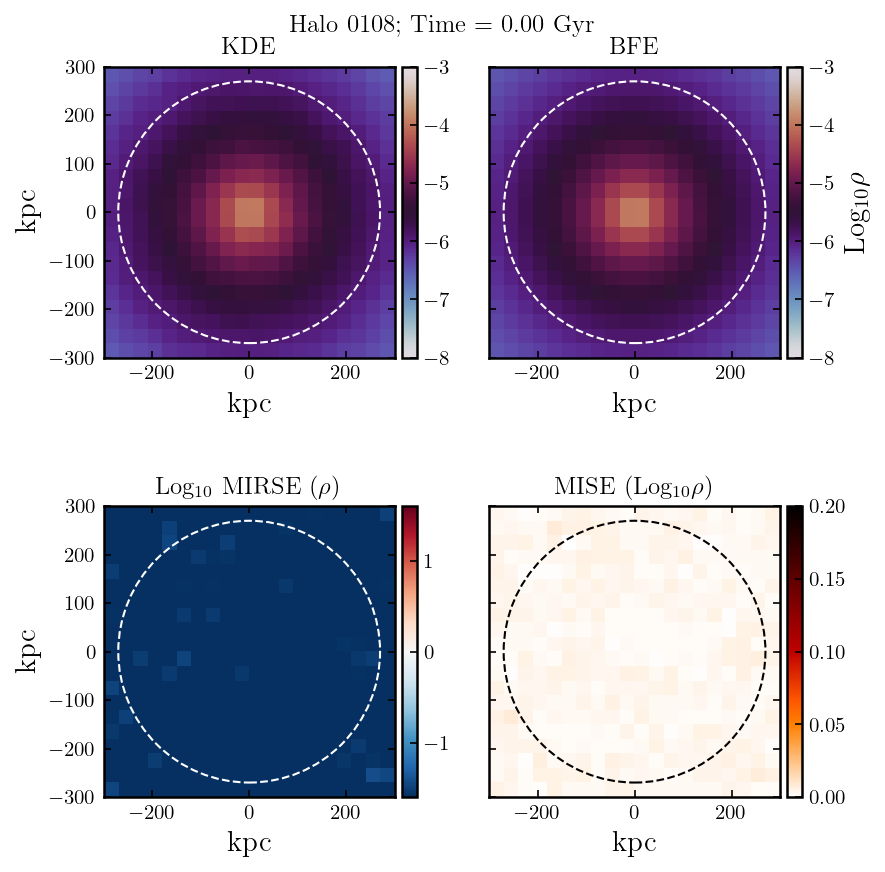

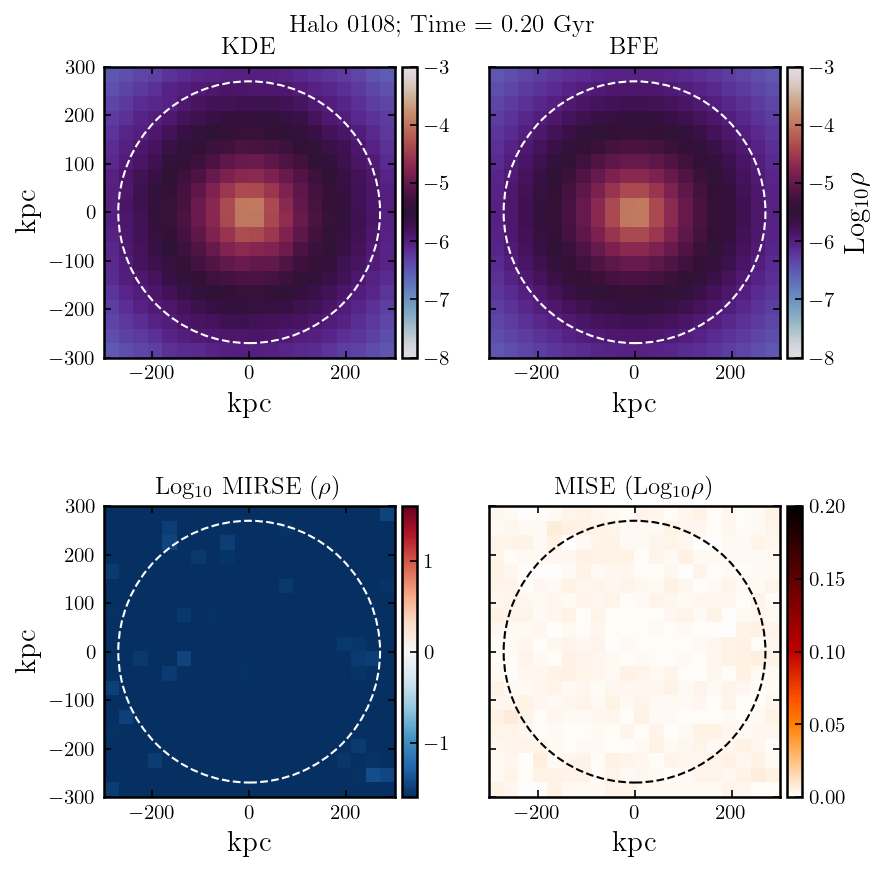

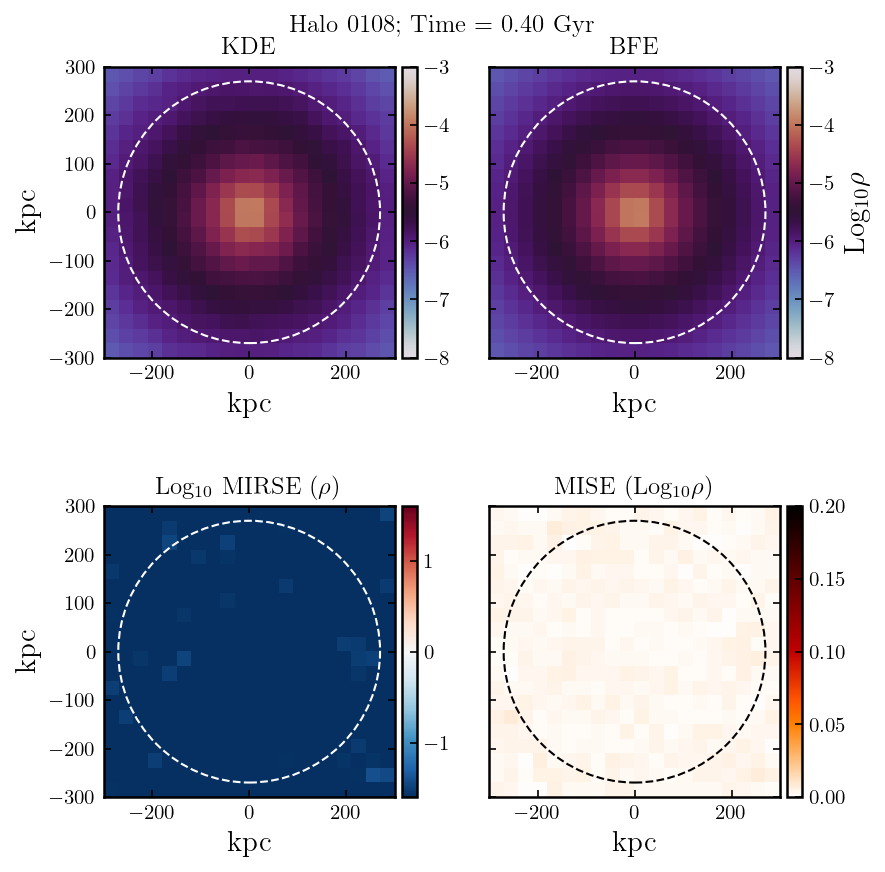

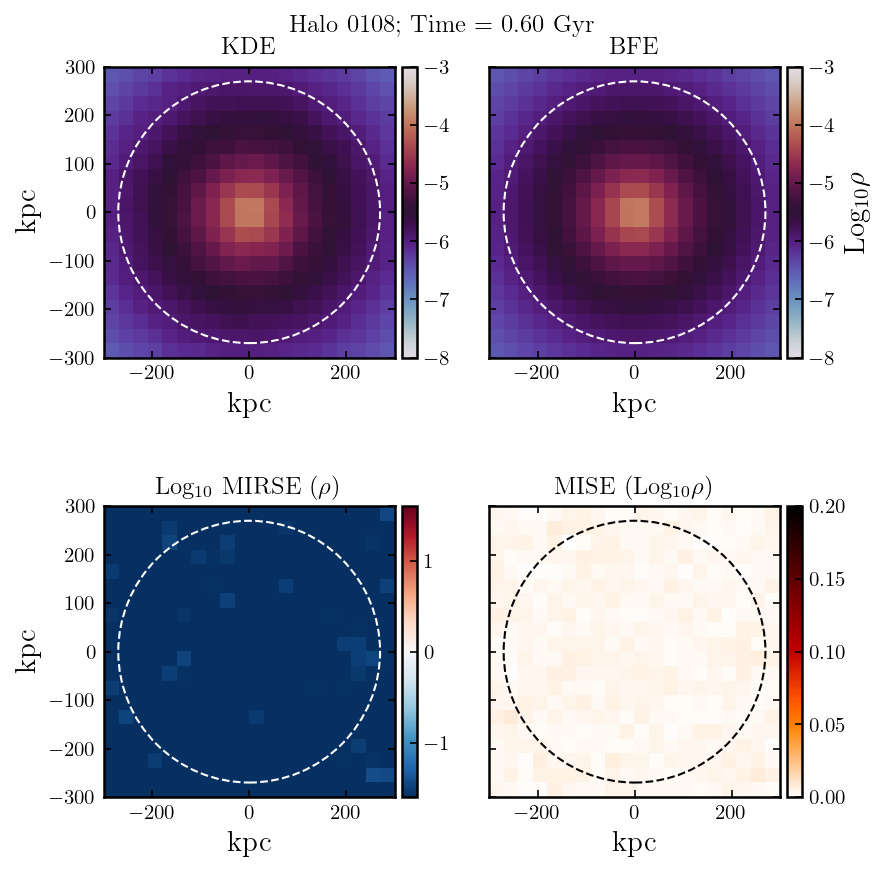

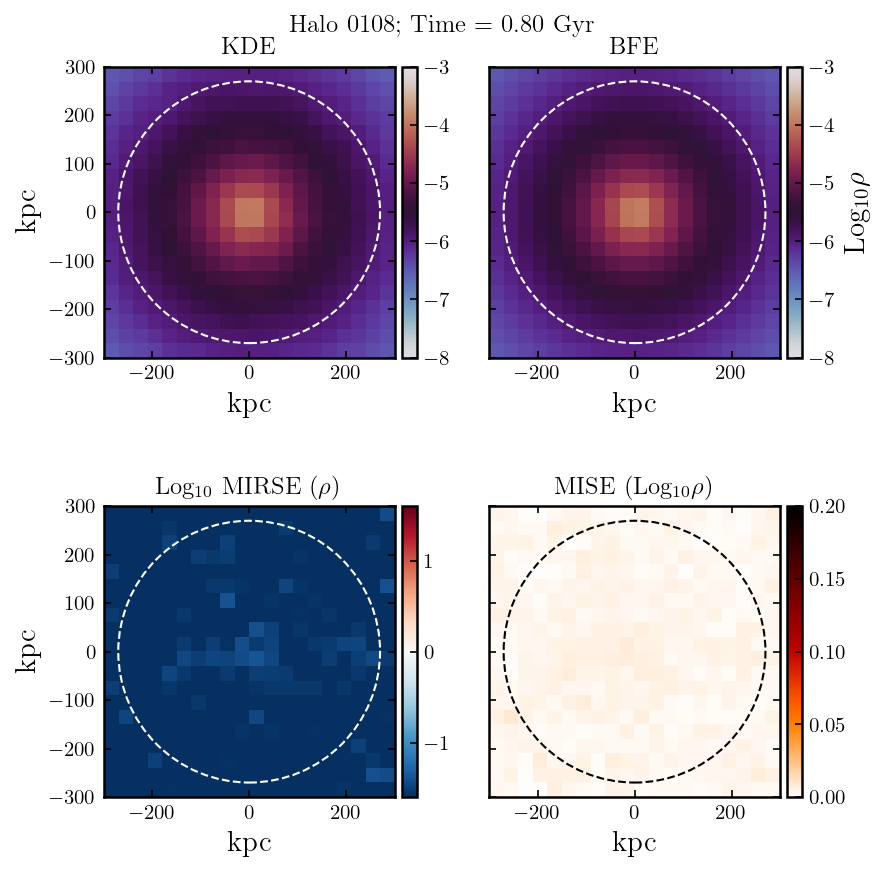

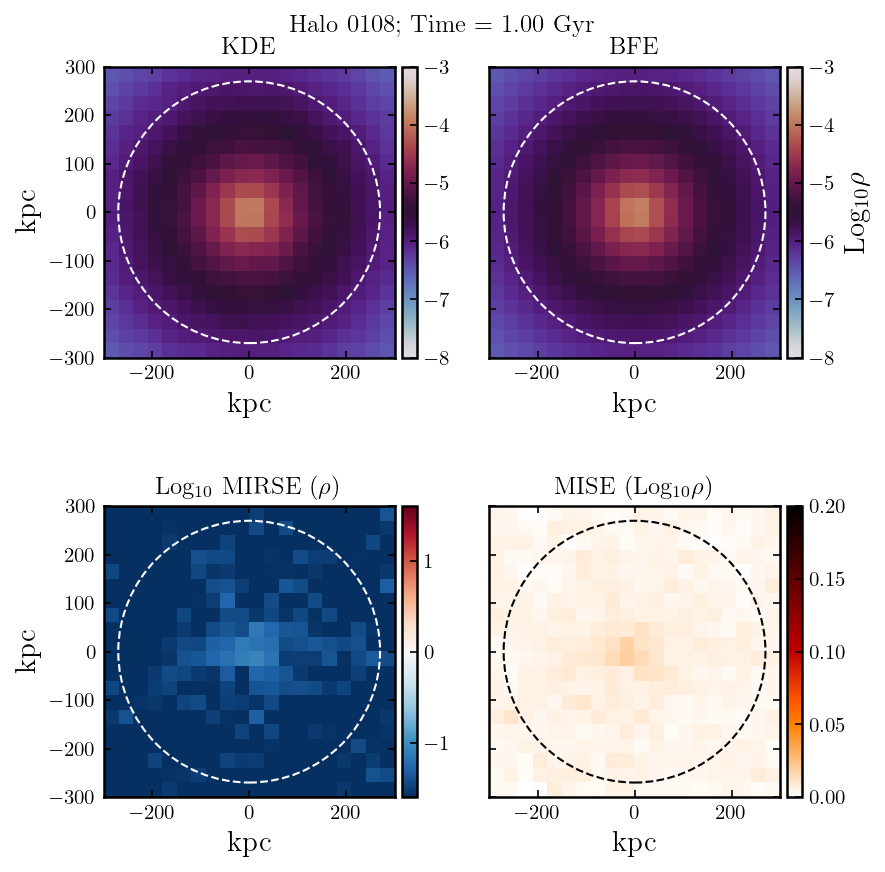

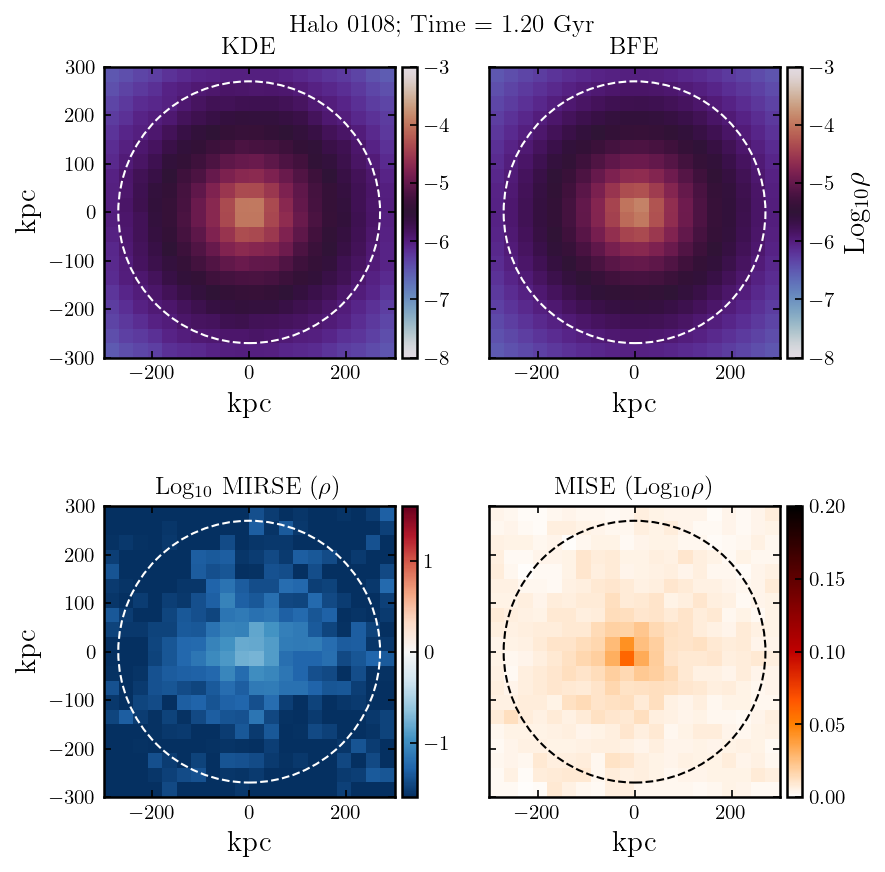

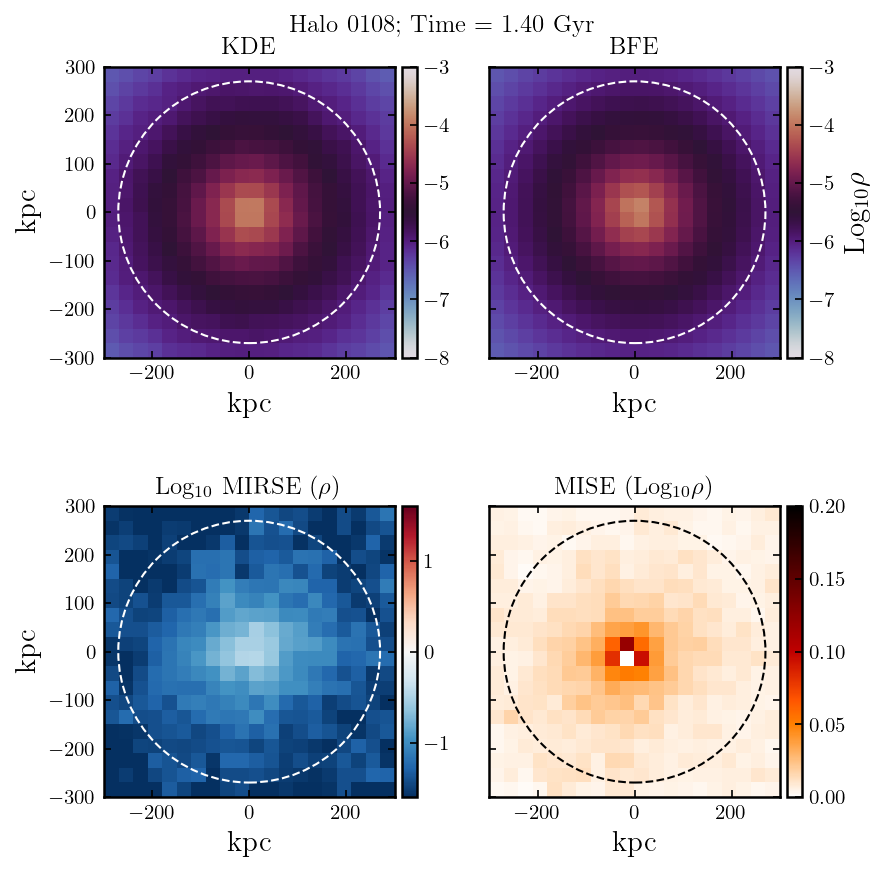

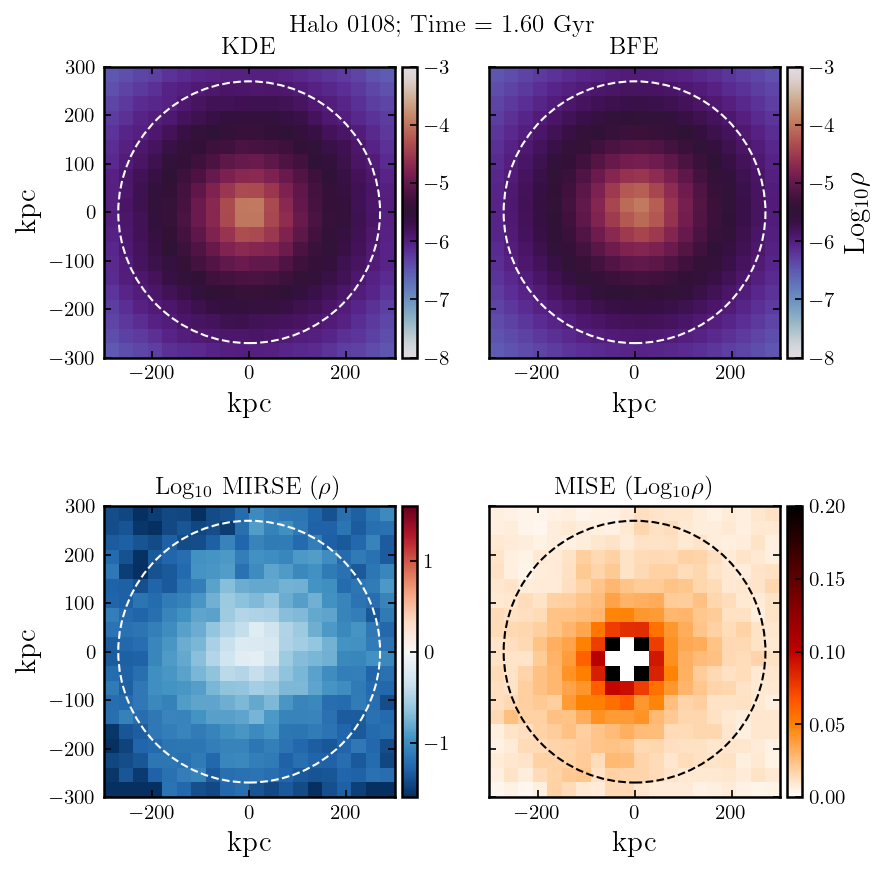

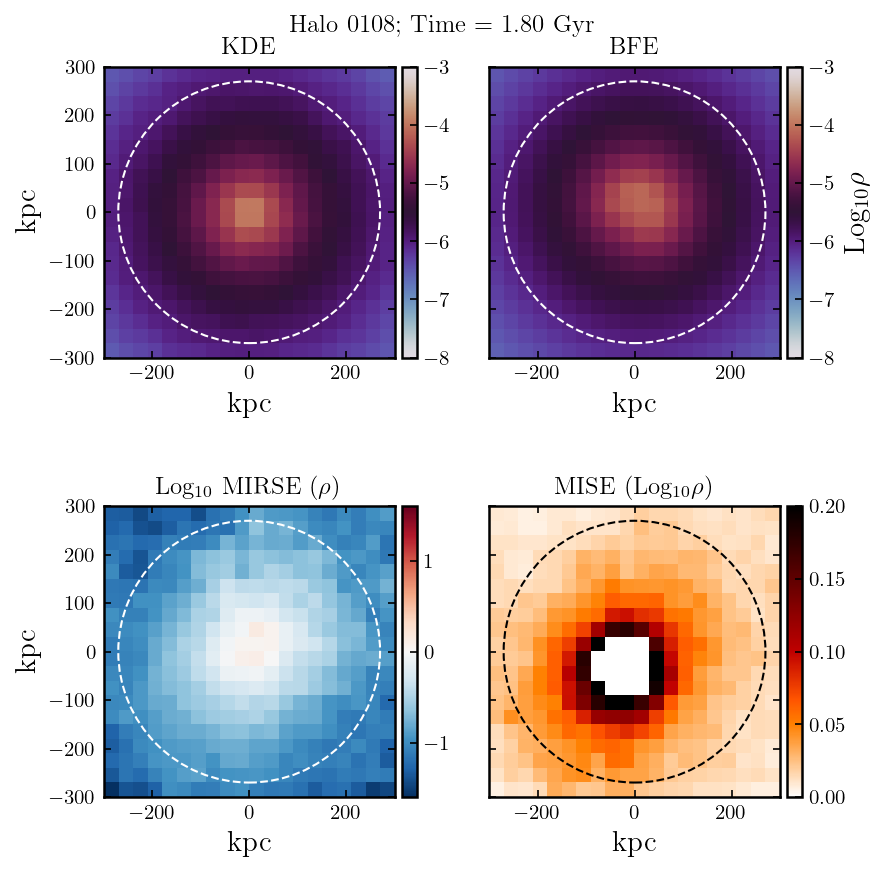

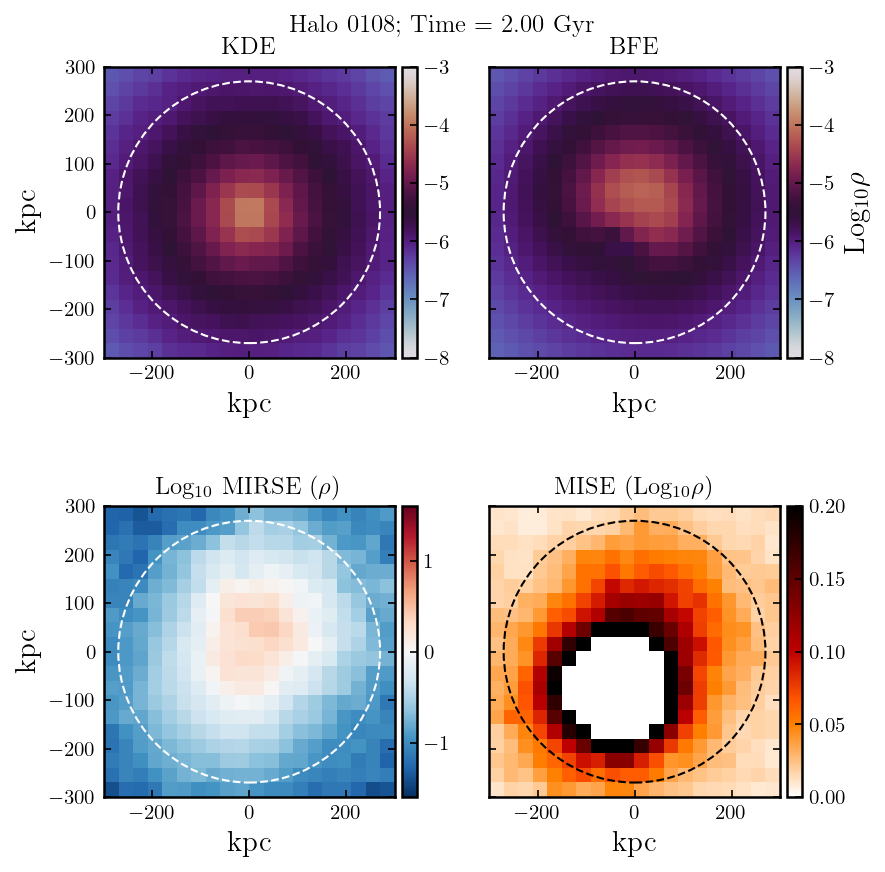

In [ ]:
for i in range(len(times)):
    fig = compute_dashboard(
        grid=grid,
        basis=basis,
        coefs=coefs,
        times=times,
        pos=p['MWhalo']['pos'],
        mass=p['MWhalo']['mass'],
        rvir=270,
        time_index=i)
    fig.suptitle("Halo {:04d}; Time = {:.2f} Gyr".format(108, times[i]))
    fig.figure.figsize = (4,4)
    fig.savefig("halo_{:04d}_density_field_{:03d}.png".format(108, i), dpi=300)

In [ ]:
dpi=300)

In [12]:
plt.figure(figsize=(4,4))
fig.show()
plt.savefig("dashboard_test.png", dpi=300)

/tmp/ipykernel_138746/2813829301.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 600x600 with 0 Axes>

In [13]:
!ls

basis_bulge_0108.yaml
basis_halo_0108.yaml
bfe_bulge_0108_density_profiles_sheng24.h5
bfe_halo_0108_density_profiles_sheng24.h5
bulge_0108_coefficients.h5
bulge_0108_density_profile_evolution.png
bulge_0108_density_profiles_sheng24.h5
cache_bulge_0108.txt
cache_halo_0108.txt
dashboard.png
dashboard_test.png
halo_0108_coefficients.h5
halo_0108_density_profile_evolution.png
halo_0108_density_profiles_sheng24.h5
modelname_bulge_0108.txt
modelname_halo_0108.txt
